# RQ1 factor A - chunking method

**What varies:** the segmentation method, five levels from Table 2.2.
**What is held constant:** BGE-small dense retrieval, no reranking, 512-unit segments, 10%
overlap, candidate depth 20, context depth 5, and the same 910 questions with the same
official 50-document candidate list.

**The centre point.** Every notebook varies one factor and holds the rest at 512-unit sliding
window segments with 10% overlap, BGE-small dense retrieval, no reranking, candidate depth 20
and context depth 5. That is what makes each measurement a *main effect*: no arm differs from
the centre in two ways at once.

**Levels**

| Level | Boundaries | Vector |
|---|---|---|
| fixed window | 512 units, no overlap | BGE-small, per chunk |
| sliding window *(centre point)* | 512 units, 10% overlap | BGE-small, per chunk |
| recursive structure-aware | official section headings, then paragraph, line, sentence | BGE-small, per chunk |
| semantic breakpoint | similarity drop past the 95th percentile | BGE-small, per chunk |
| late chunking | sliding-window boundaries | long-context encoder, pooled from the whole Technote |

Late chunking changes the encoder as well as the pooling, so it is also compared against a
**matched control** - identical boundaries, identical encoder, ordinary pooling. Only that
comparison isolates late chunking; the headline table reports both.

**Runtime:** about 4 minutes. Everything expensive was built by notebook 00.

## 1. Open the shared cache

In [1]:
# Load the shared library written by notebook 00 and open the same cache.
import sys, os
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/techqa_rq1'
assert os.path.exists(PROJECT + '/rq1_core.py'), (
    'rq1_core.py not found. Run RQ1_00_Build_Once.ipynb first - it writes the library '
    'and builds the chunk tables and embeddings that this notebook reads from cache.')
sys.path.insert(0, PROJECT)
import rq1_core as C
import numpy as np, pandas as pd, time, json
C.setup(project_dir=PROJECT)
print('GPU:', C.gpu_name())

Mounted at /content/drive
rq1_core 1.0 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
GPU: Tesla T4


In [2]:
# The whole labelled dataset, on the fast local disk.
# Notebook 00 mirrors the four extracted files to Drive, so this fresh runtime restores them
# with a file copy (~1 min) instead of re-downloading and re-extracting the archive (~5 min).
if not C.dataset_present():
    if C.dataset_mirrored():
        print('restoring the corpus from the Drive mirror ...')
        C.restore_dataset_from_mirror()
    else:
        dl, ex = C.download_commands()
        get_ipython().system(dl)
        get_ipython().system(ex)
        C.mirror_dataset()
ds = C.load_dataset()
print(json.dumps(ds.summary(), indent=1))

restoring the corpus from the Drive mirror ...
{
 "questions": 910,
 "answerable": 610,
 "unanswerable": 300,
 "per_split": {
  "train": [
   600,
   450
  ],
  "dev": [
   310,
   160
  ]
 },
 "technotes": 28482,
 "candidate_technotes": 28461
}


## 2. Retrieval for every chunking method

Each question searches only the chunks of its own 50 official candidate Technotes, so one question is a matrix slice and a dot product rather than an index search.

In [3]:
from tqdm.auto import tqdm
METHODS = list(C.CFG.CHUNK_METHODS)
CONTROL = C.CFG.LATE_CONTROL

frames, contexts, cost = [], {}, []
for m in METHODS + [CONTROL]:
    try:
        idx = C.load_method_index(ds, m)
    except FileNotFoundError as e:
        print(f'{m:<24} SKIPPED - {e}')
        continue
    t0 = time.perf_counter()
    df, latency = C.run_arm(idx, ds.questions, retriever='dense', arm_name=m)
    contexts[m] = {q['QUESTION_ID']: C.top_context(idx, q, 'dense').tolist()
                   for q in ds.questions}
    frames.append(df)
    cost.append({'method': m, 'chunks': len(idx.table),
                 'chunking_s': idx.timings.get('chunking_s'),
                 'embedding_s': idx.timings.get('embedding_s'),
                 'retrieval_ms': latency * 1000,
                 'whole_matrix_s': time.perf_counter() - t0})
    print(f'{m:<24} {len(df):>4} questions scored   {latency*1000:6.2f} ms/query')
    del idx; C.free_gpu()

A = pd.concat(frames, ignore_index=True)
cost_A = pd.DataFrame(cost)
json.dump(contexts, open(C.PATHS.CACHE / 'contexts_factorA.json', 'w'))
C.save_table(A, 'rq1_factorA_per_question')
print('\nrows:', len(A), '| methods:', sorted(A.method.unique()))

fixed_window              610 questions scored     0.04 ms/query
sliding_window            610 questions scored     0.06 ms/query
recursive_structure       610 questions scored     0.04 ms/query
semantic_breakpoint       610 questions scored     0.08 ms/query
late_chunking             610 questions scored     0.05 ms/query
sliding_window_longctx    610 questions scored     0.07 ms/query
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA_per_question.csv

rows: 3660 | methods: ['fixed_window', 'late_chunking', 'recursive_structure', 'semantic_breakpoint', 'sliding_window', 'sliding_window_longctx']


## 3. The metric profile per method

Means over the 610 answerable questions, each with a 95% bootstrap interval obtained by resampling questions.

In [4]:
METRICS = C.RETRIEVAL_METRICS
summary_A = C.arm_summary(A, ['method'], METRICS)
summary_A['method'] = pd.Categorical(summary_A['method'],
                                     categories=METHODS + [CONTROL], ordered=True)
summary_A = summary_A.sort_values('method')
display(summary_A[['method', 'n'] + METRICS].round(4))
C.save_table(summary_A, 'rq1_factorA_summary')

,method,n,nDCG@5,Recall@20,MRR,gold_span_coverage,context_precision@5,context_recall@5,gold_document_in_top_5,chunk_boundary_loss
0,fixed_window,610,0.5673,0.8361,0.5506,0.6439,0.1298,0.6439,0.6672,0.0246
4,sliding_window,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262
2,recursive_structure,610,0.5685,0.8328,0.5533,0.6230,0.1256,0.6230,0.6672,0.0443
3,semantic_breakpoint,610,0.5434,0.8049,0.5340,0.4647,0.1007,0.4647,0.6148,0.1672
1,late_chunking,610,0.6031,0.8508,0.5825,0.6882,0.1390,0.6882,0.7049,0.0180
5,sliding_window_longctx,610,0.6116,0.8557,0.5907,0.6944,0.1403,0.6944,0.7115,0.0197


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA_summary.csv


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA_summary.csv')

  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorA_profile.png


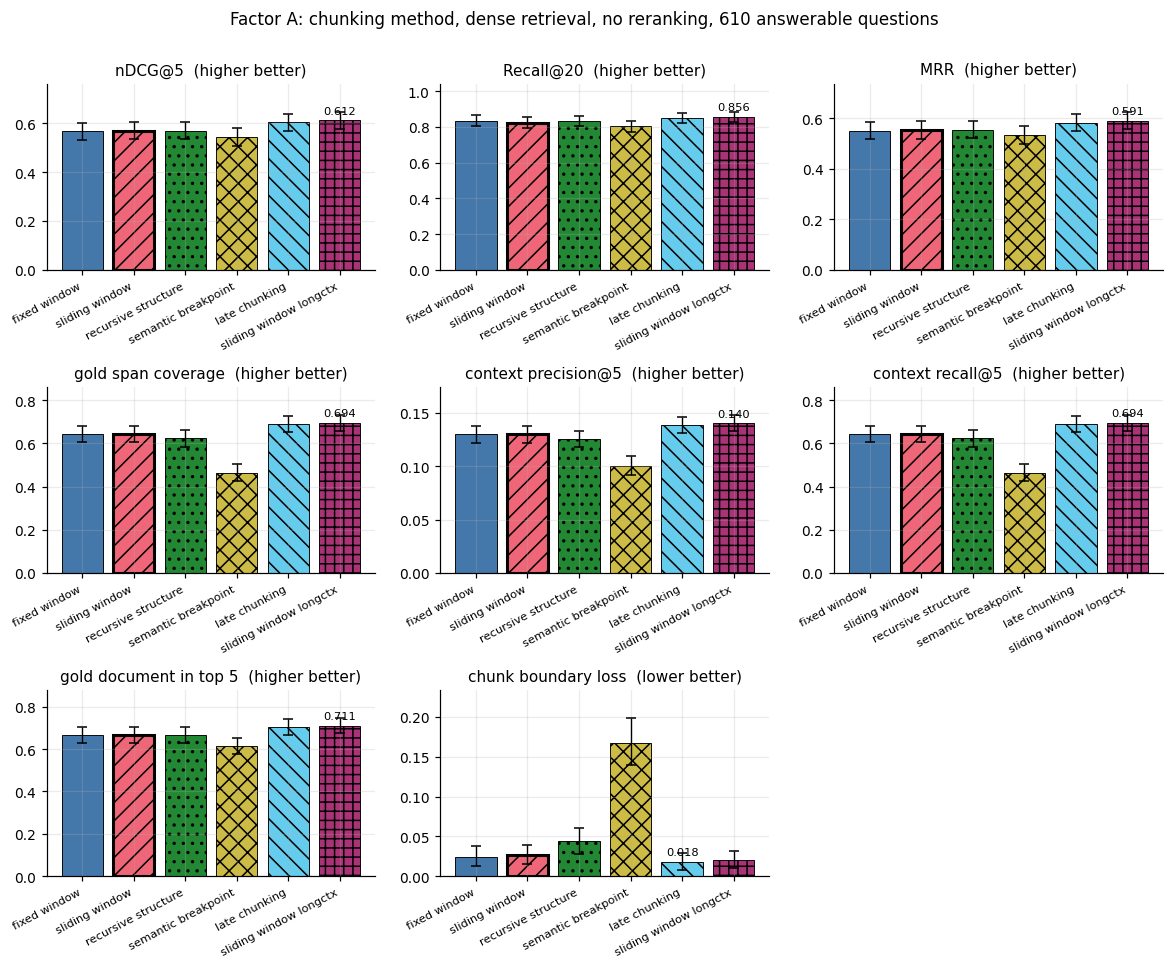

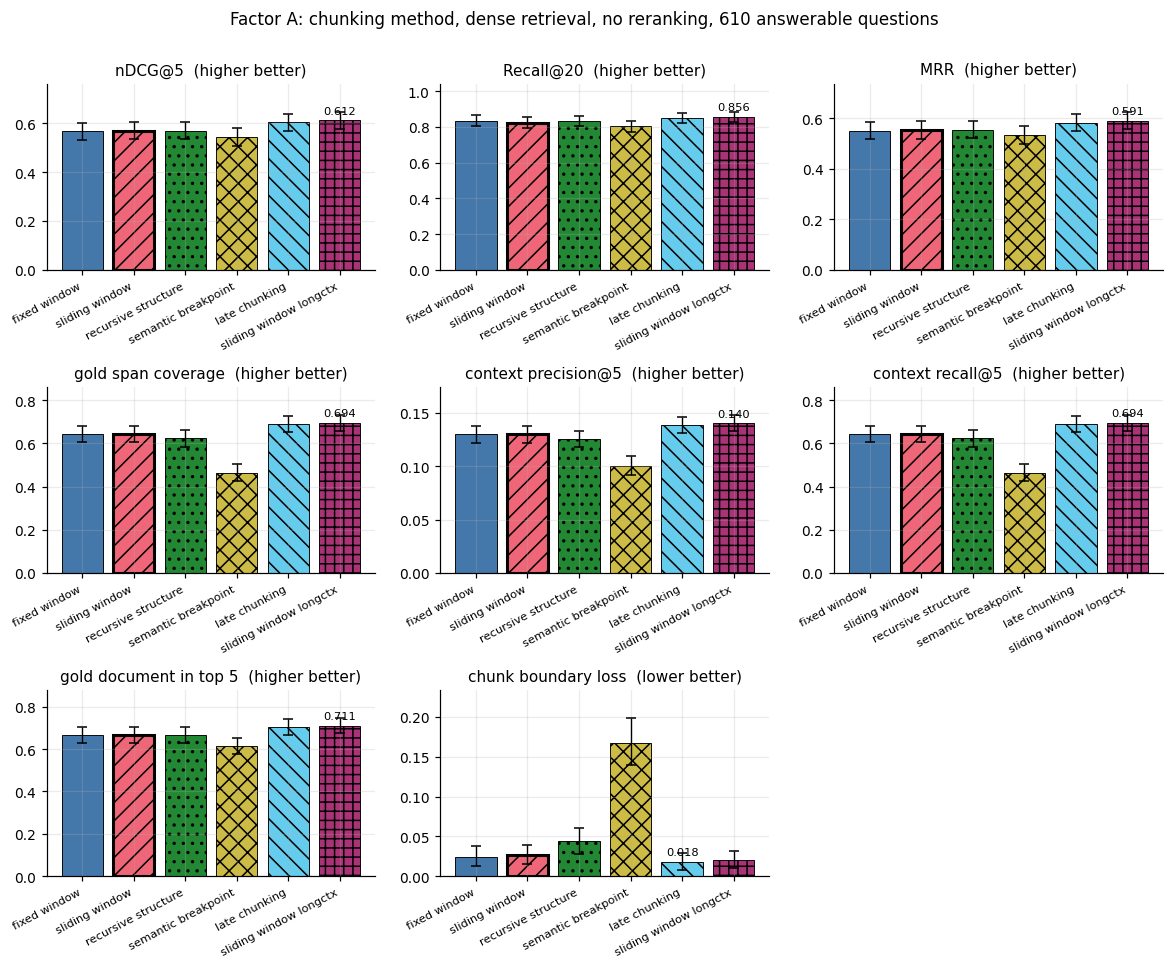

In [5]:
C.plot_metric_bars(summary_A, 'method', METRICS,
    'Factor A: chunking method, dense retrieval, no reranking, 610 answerable questions',
    'fig_rq1_factorA_profile', baseline=C.CFG.BASELINE_METHOD,
    caption='Retrieval-evidence profile of the five chunking methods over all 610 answerable '
            'TechQA questions, with BGE-small dense retrieval and no reranking. Error bars are '
            '95% bootstrap intervals over questions. The outlined bar is the frozen '
            'configuration of Section 5.3.')

## 4. Is any method actually different from the centre point?

Paired bootstrap over the same questions, Holm-corrected across the four contrasts within each metric. An interval that crosses zero is a difference this sample size cannot resolve, and is reported as such rather than as a ranking.

,level,level_mean,baseline_mean,mean_diff,lo,hi,p_holm,significant,n
0,fixed_window,0.5673,0.5693,-0.0020,-0.0087,0.0051,1.0000,False,610
1,late_chunking,0.6031,0.5693,0.0338,0.0098,0.0584,0.0228,True,610
2,recursive_structure,0.5685,0.5693,-0.0008,-0.0107,0.0093,1.0000,False,610
3,semantic_breakpoint,0.5434,0.5693,-0.0259,-0.0435,-0.0083,0.0160,True,610
4,sliding_window_longctx,0.6116,0.5693,0.0423,0.0189,0.0664,0.0020,True,610


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA_contrasts.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorA_forest.png


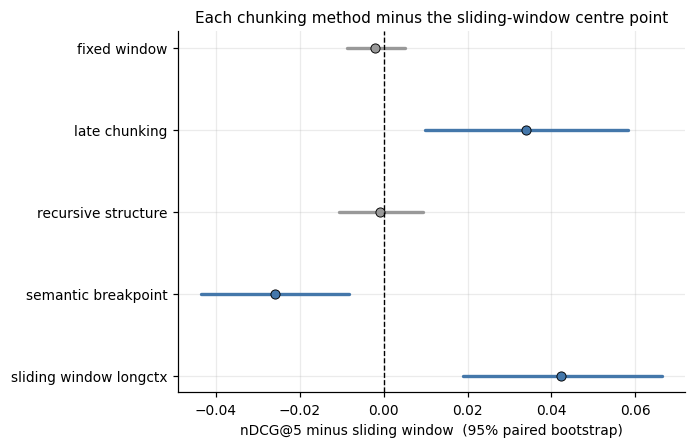

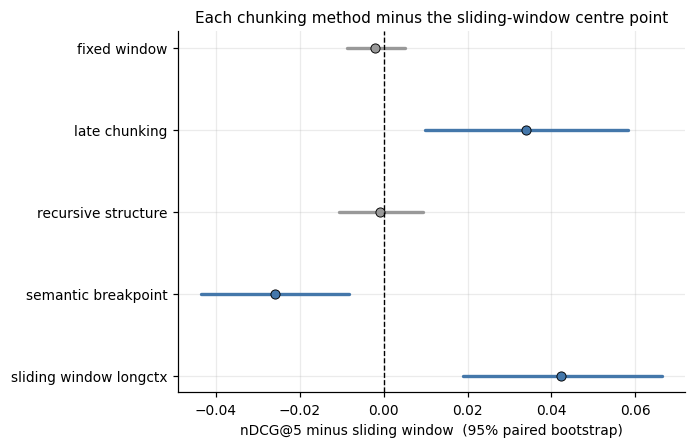

In [6]:
contrasts_A = C.pairwise_against_baseline(A, 'method', C.CFG.BASELINE_METHOD, METRICS)
display(contrasts_A[contrasts_A.metric == 'nDCG@5'][
    ['level', 'level_mean', 'baseline_mean', 'mean_diff', 'lo', 'hi', 'p_holm',
     'significant', 'n']].round(4))
C.save_table(contrasts_A, 'rq1_factorA_contrasts')
C.plot_forest(contrasts_A, 'nDCG@5',
    'Each chunking method minus the sliding-window centre point', 'fig_rq1_factorA_forest',
    caption='Paired bootstrap 95% intervals for nDCG@5 of each chunking method minus the '
            'sliding-window centre point, over the questions scored by both arms. Grey '
            'intervals cross zero.')

## 5. Late chunking against its matched control

The honest comparison. Late chunking against the BGE-small sliding window mixes two changes; against its control it isolates one.

In [7]:
if 'late_chunking' in set(A.method) and CONTROL in set(A.method):
    rows = []
    for metric in METRICS:
        w = C.to_wide(A[A.method.isin(['late_chunking', CONTROL])], metric, 'method')
        if w.empty: continue
        r = C.paired_bootstrap(w['late_chunking'].values, w[CONTROL].values)
        r.update(metric=metric, comparison='late chunking minus matched long-context control')
        rows.append(r)
        naive = C.to_wide(A[A.method.isin(['late_chunking', C.CFG.BASELINE_METHOD])],
                          metric, 'method')
        r2 = C.paired_bootstrap(naive['late_chunking'].values,
                                naive[C.CFG.BASELINE_METHOD].values)
        r2.update(metric=metric, comparison='late chunking minus BGE-small sliding window')
        rows.append(r2)
    late = pd.DataFrame(rows)
    display(late[['comparison', 'metric', 'mean_diff', 'lo', 'hi', 'p_two_sided', 'n']]
            .round(4))
    C.save_table(late, 'rq1_factorA_late_chunking')
    for _, r in late[late.metric == 'nDCG@5'].iterrows():
        print('\n' + C.describe_contrast(
            {'level': 'late chunking', 'baseline': r['comparison'].split('minus')[1].strip(),
             'mean_diff': r.mean_diff, 'lo': r.lo, 'hi': r.hi, 'n': r.n, 'metric': 'nDCG@5'}))
else:
    print('late chunking was not built - set BUILD_LATE_CHUNKING = True in notebook 00')

,comparison,metric,mean_diff,lo,hi,p_two_sided,n
0,late chunking minus matched long-context control,nDCG@5,-0.0085,-0.0173,-0.0004,0.0400,610
1,late chunking minus BGE-small sliding window,nDCG@5,0.0338,0.0098,0.0584,0.0076,610
2,late chunking minus matched long-context control,Recall@20,-0.0049,-0.0197,0.0098,0.5896,610
3,late chunking minus BGE-small sliding window,Recall@20,0.0262,0.0000,0.0541,0.0580,610
4,late chunking minus matched long-context control,MRR,-0.0082,-0.0171,-0.0000,0.0500,610
5,late chunking minus BGE-small sliding window,MRR,0.0296,0.0053,0.0538,0.0192,610
6,late chunking minus matched long-context control,gold_span_coverage,-0.0062,-0.0190,0.0053,0.3332,610
7,late chunking minus BGE-small sliding window,gold_span_coverage,0.0446,0.0164,0.0741,0.0024,610
8,late chunking minus matched long-context control,context_precision@5,-0.0013,-0.0039,0.0013,0.3588,610
9,late chunking minus BGE-small sliding window,context_precision@5,0.0092,0.0033,0.0151,0.0012,610


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA_late_chunking.csv

late chunking against matched long-context control gives a mean difference of -0.0085 in nDCG@5, with a 95% interval from -0.0173 to -0.0004 over 610 paired questions. The interval excludes zero.

late chunking against BGE-small sliding window gives a mean difference of +0.0338 in nDCG@5, with a 95% interval from +0.0098 to +0.0584 over 610 paired questions. The interval excludes zero.


## 6. Cost, and what factor A contributes to RQ1

,method,chunks,chunking_s,embedding_s,retrieval_ms,whole_matrix_s
0,fixed_window,37711,7.94,182.07,0.04,0.08
1,sliding_window,38046,7.85,193.40,0.06,0.12
2,recursive_structure,42409,16.95,194.81,0.04,0.08
3,semantic_breakpoint,83962,1371.94,294.67,0.08,0.16
4,late_chunking,38046,6.41,1649.91,0.05,0.10
5,sliding_window_longctx,38046,5.18,1908.23,0.07,0.15


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA_cost.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorA_cost.png
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorA.json
Chunking method, nDCG@5: levels span 0.0598 (95% CI 0.0343 to 0.0858), partial eta-squared 0.0152, best level late_chunking.

Factor A complete. Run RQ1_B_Retrieval_Strategy.ipynb next.


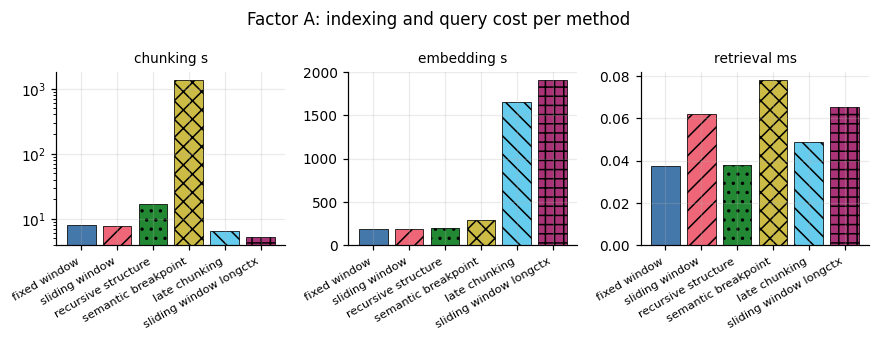

In [8]:
display(cost_A.round(2))
C.save_table(cost_A, 'rq1_factorA_cost')
C.plot_cost(cost_A, 'fig_rq1_factorA_cost', 'Factor A: indexing and query cost per method',
            caption='Indexing and query cost of each chunking method over the whole corpus.')

eff_A = C.repeated_measures_effect(C.to_wide(A[A.method.isin(METHODS)], 'nDCG@5', 'method'))
C.save_results({'effect_nDCG@5': eff_A,
                'summary': summary_A.to_dict(orient='records'),
                'provenance': C.stamp({'factor': 'chunking_method'})}, 'rq1_factorA')
print(f"Chunking method, nDCG@5: levels span {eff_A['range']:.4f} "
      f"(95% CI {eff_A['range_lo']:.4f} to {eff_A['range_hi']:.4f}), "
      f"partial eta-squared {eff_A['eta2_partial']:.4f}, best level {eff_A['best_level']}.")
print('\nFactor A complete. Run RQ1_B_Retrieval_Strategy.ipynb next.')